# Optimistic Initial Values vs. Realistic ε-Greedy

This notebook compares two agents on a stationary 10-armed bandit:
- **Optimistic, Greedy**: Q₁ = 5.0, ε = 0.0
- **Realistic, ε-greedy**: Q₁ = 0.0, ε = 0.1

Both agents use a constant step size (α = 0.1). The goal is to see how an optimistic initial value estimate can drive early exploration on its own — even with a fully greedy (ε = 0) policy — and how this compares to explicit random exploration via ε-greedy.

In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt


module_path = Path.cwd().parent.resolve()

if str(module_path) not in sys.path:
    sys.path.append(str(module_path))


from bandit_engine import gaussian_arms_factory
from agents import EpsilonGreedyAgent
from run_experiments import compare_agents
from utils import plot_bandit_performance

In [5]:
RANDOM_SEED = 42
k_arms = 10

agent_configs = [
    {
        "label": "Optimistic, Greedy\nQ1 = 5.0, eps=0.0",
        "agent_type": EpsilonGreedyAgent,
        "agent_config": {
            "n_arms": k_arms,
            "epsilon": 0.0,
            "initial_value": 5.0,
            "alpha": 0.1
        }
    },
    {
        "label": "Realistic, e-greedy\nQ1=0, eps=0.1",
        "agent_type": EpsilonGreedyAgent,
        "agent_config": {
            "n_arms": k_arms,
            "epsilon": 0.1,
            "initial_value": 0.0,
            "alpha": 0.1
        }
    }
]

# Set experiment parameters and run comparison
n_runs = 2000
n_steps = 1000
non_stationary = False

results = compare_agents(
    arm_factory=gaussian_arms_factory,
    agent_configs=agent_configs,
    random_seed=RANDOM_SEED,
    n_runs=n_runs,
    n_steps=n_steps,
    non_stationary=non_stationary
)

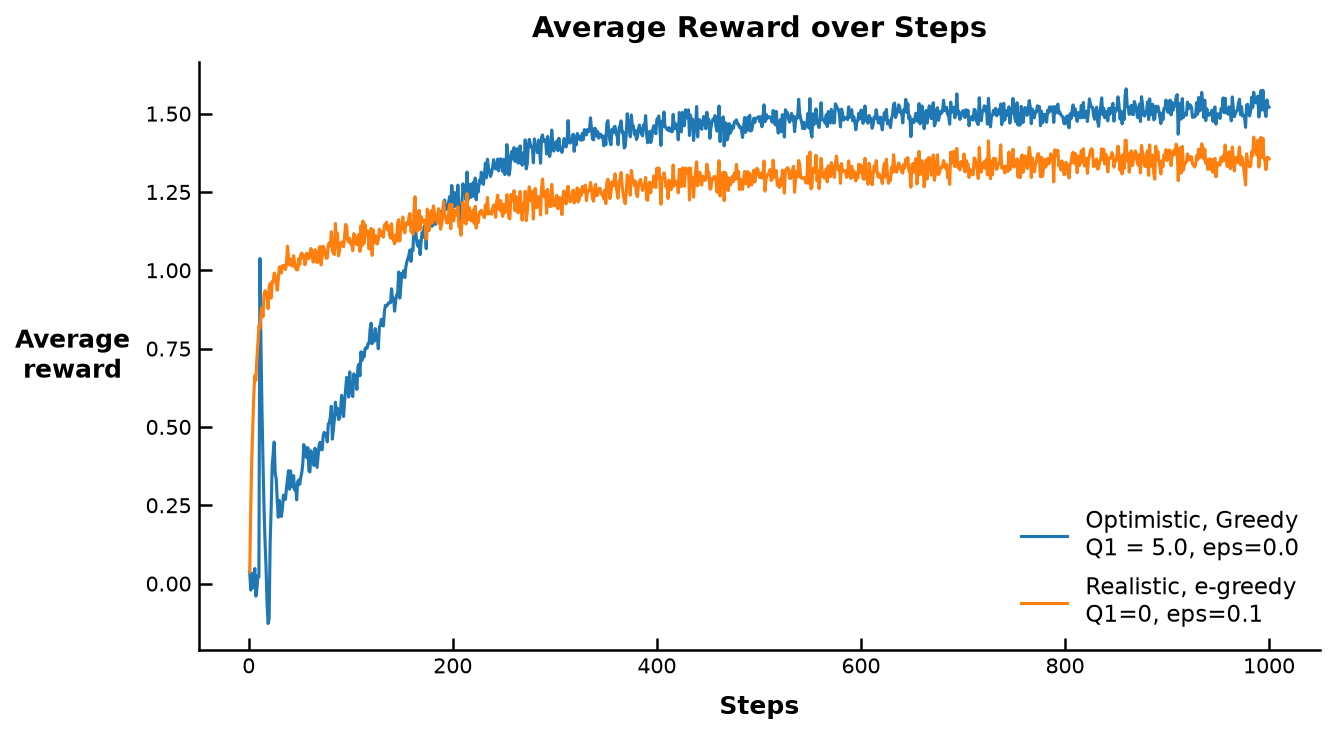

In [ ]:
# Unpack the results tuple into separate dictionaries for each metric
rewards_dict = {label: data[0] for label, data in results.items()}
optimal_actions_dict = {label: data[1] for label, data in results.items()}

# Custom color mapping matching the agent labels used in agent_configs
custom_colors = {
    "Optimistic": "#1F77B4",
    "Realistic": "#FF7F0E"
}

fig_reward, ax_reward = plot_bandit_performance(
    metrics_data=rewards_dict,
    metric_type="reward",
    title="Average Reward over Steps",
    colors=custom_colors
)

plt.show()

## Observations:
- Although the optimistic agent (Q₁ = 5.0, ε = 0.0) is fully greedy, its inflated initial estimates make every action look disappointing the first few times it's tried — since the observed reward is almost always lower than 5.0, the agent's estimates keep getting revised downward, causing it to keep switching to other actions it hasn't tried yet. This produces "built-in" exploration purely from the optimistic initialization, visible here as the sharp early oscillations in average reward as the agent cycles through under-sampled actions before its estimates stabilize.
- Because this exploration is front-loaded early in training and the constant step-size (α = 0.1) preserves a meaningful trace of the initial bias for a while, the optimistic agent locates the high-value actions relatively early and can spend the rest of the run mostly exploiting them, resulting in the highest long-run average reward (~1.5).
- The realistic agent (Q₁ = 0, ε = 0.1) explores continuously throughout the entire run rather than concentrating exploration early. This gives it a head start in the first ~150 steps, but its exploration never fully "switches off" — it keeps spending 10% of steps on non-greedy actions indefinitely, even after it already knows which action is optimal. This constant, unfocused exploration cost is why it converges to a lower average reward (~1.35) than the optimistic agent.

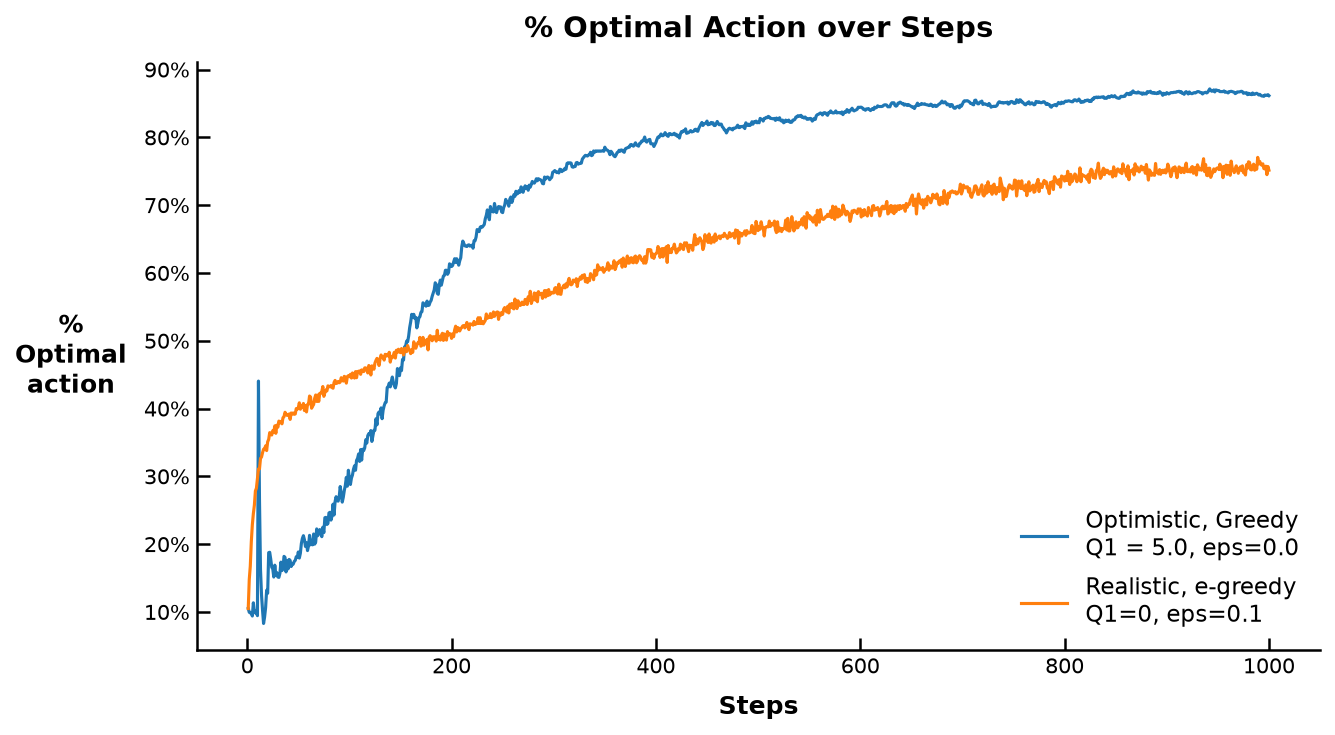

In [7]:
fig_optimal, ax_optimal = plot_bandit_performance(
    metrics_data=optimal_actions_dict,
    metric_type="optimal_action",
    title="% Optimal Action over Steps",
    colors=custom_colors
)
plt.show()

## Observations:
- This plot highlights the exploration mechanism even more clearly. Despite ε = 0.0, the optimistic agent starts with a very low and volatile optimal-action rate, since its inflated Q₁ = 5.0 estimates push it to systematically try under-sampled actions — a form of exploration driven entirely by the pessimistic surprise of real rewards falling short of the optimistic prior, rather than by randomness.
- Once its estimates settle down (roughly by step 150–200), the agent has already sampled most actions enough to identify the truly optimal one, and — being purely greedy — it exploits that knowledge relentlessly, driving its optimal-action rate up sharply to nearly 87%.
- The realistic ε-greedy agent explores more efficiently at the very start (no initial "unlearning" period), giving it an early lead. However, its fixed 10% random-exploration rate persists forever, meaning even late in training it still wastes a constant fraction of steps on non-optimal actions. This caps its optimal-action rate at a lower plateau (~75%) compared to the optimistic greedy agent.